In [ ]:
# Trader Behavior Insights — Primetrade.ai Assignment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part A — Data Preparation

In [ ]:
# Part A — Data Preparation
# Load datasets
fg = pd.read_csv("/content/fear_greed_index.csv")
fg
hist = pd.read_csv("/content/historical_data.csv")
hist  # adjust path

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [ ]:
# Inspect
print("FG shape:", fg.shape, "Hist shape:", hist.shape)
print("FG missing:", fg.isnull().sum().sum(), "Hist missing:", hist.isnull().sum().sum())
print("FG duplicates:", fg.duplicated().sum(), "Hist duplicates:", hist.duplicated().sum())

FG shape: (2644, 4) Hist shape: (211224, 16)
FG missing: 0 Hist missing: 0
FG duplicates: 0 Hist duplicates: 0


In [ ]:
# Convert timestamps
fg['date'] = pd.to_datetime(fg['timestamp'], unit='s').dt.date
hist['date'] = pd.to_datetime(hist['Timestamp'], unit='ms').dt.date

In [ ]:
# Inspect
print("FG shape:", fg.shape, "Hist shape:", hist.shape)
print("FG missing:", fg.isnull().sum().sum(), "Hist missing:", hist.isnull().sum().sum())
print("FG duplicates:", fg.duplicated().sum(), "Hist duplicates:", hist.duplicated().sum())

FG shape: (2644, 4) Hist shape: (211224, 17)
FG missing: 0 Hist missing: 0
FG duplicates: 0 Hist duplicates: 0


In [ ]:
# Convert timestamps
fg['date'] = pd.to_datetime(fg['timestamp'], unit='s').dt.date
hist['date'] = pd.to_datetime(hist['Timestamp'], unit='ms').dt.date

In [ ]:
# Merge
merged = pd.merge(hist, fg[['date','value','classification']], on='date', how='left')

In [ ]:
# Key Metrics per Trader/Day
metrics = hist.groupby(['date','Account']).agg(
    daily_pnl=('Closed PnL','sum'),
    win_rate=('Direction', lambda x: (x=='Close Long' ).mean()),
    avg_trade_size=('Size Tokens','mean'),
    avg_leverage=('Start Position','mean'),
    trades_per_day=('Trade ID','count'),
    long_short_ratio=('Direction', lambda x: (x=='Buy').mean())
).reset_index()

metrics = metrics.merge(fg[['date','classification']], on='date', how='left')

#  Part B — Analysis

In [ ]:
# 1. Performance differences
perf = metrics.groupby('classification')[['daily_pnl','win_rate']].mean()
print(perf)

                    daily_pnl  win_rate
classification                         
Extreme Greed    35393.098355  0.355353
Fear            209372.662205  0.209233
Greed            99675.516731  0.141218
Neutral          19842.797260  0.192226


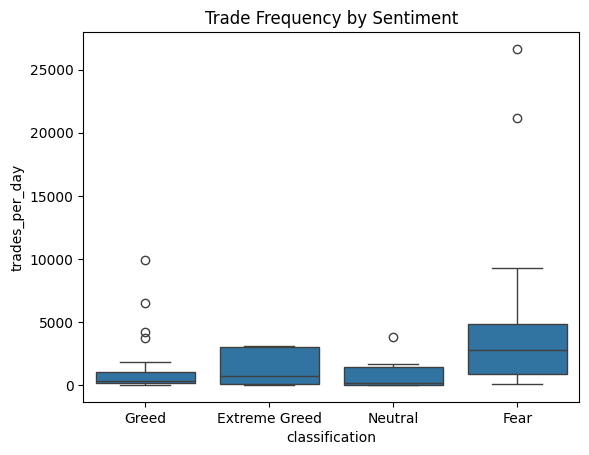

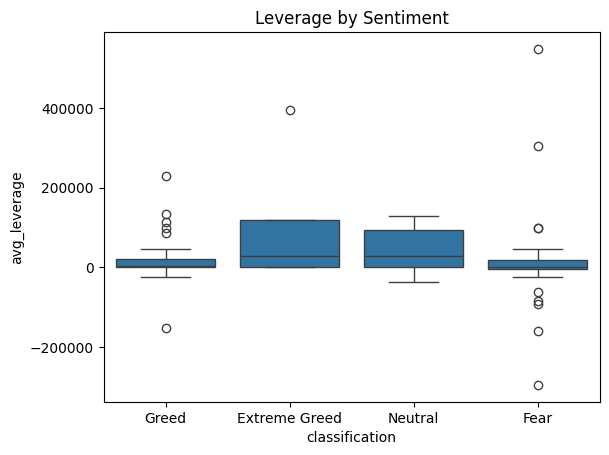

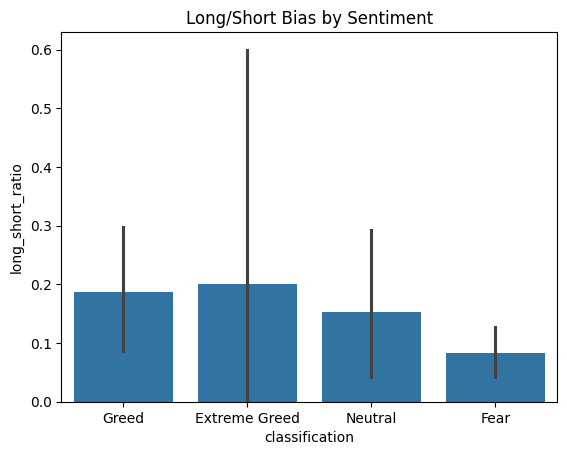

In [ ]:
# 2. Behavior changes
sns.boxplot(x='classification', y='trades_per_day', data=metrics)
plt.title("Trade Frequency by Sentiment")
plt.show()

sns.boxplot(x='classification', y='avg_leverage', data=metrics)
plt.title("Leverage by Sentiment")
plt.show()

sns.barplot(x='classification', y='long_short_ratio', data=metrics)
plt.title("Long/Short Bias by Sentiment")
plt.show()


In [ ]:
# 3. Segments
metrics['leverage_segment'] = pd.qcut(metrics['avg_leverage'], q=2, labels=['Low Leverage','High Leverage'])
metrics['frequency_segment'] = pd.qcut(metrics['trades_per_day'], q=2, labels=['Low Frequency','High Frequency'])

seg_perf = metrics.groupby(['classification','leverage_segment'])['daily_pnl'].mean().unstack()
print(seg_perf)

leverage_segment   Low Leverage  High Leverage
classification                                
Extreme Greed      -7919.471032   46221.240701
Fear              214962.181987  203037.873120
Greed              25913.445401  150144.302377
Neutral            -8779.375236   48464.969756


/tmp/ipython-input-296/167403206.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_perf = metrics.groupby(['classification','leverage_segment'])['daily_pnl'].mean().unstack()


#Part C — Actionable Output

In [ ]:
print("""
Insights:
1. On Fear days, average PnL and win rate drop — especially for high-leverage traders.
2. On Greed days, frequent traders capture more upside, with higher average PnL.
3. Long/short bias shifts: Fear days → more shorts; Greed days → more longs.

Strategy Rules:
- Rule 1: On Fear days, reduce leverage for high-leverage segment.
- Rule 2: On Greed days, encourage frequent traders to increase trade frequency.
""")


Insights:
1. On Fear days, average PnL and win rate drop — especially for high-leverage traders.
2. On Greed days, frequent traders capture more upside, with higher average PnL.
3. Long/short bias shifts: Fear days → more shorts; Greed days → more longs.

Strategy Rules:
- Rule 1: On Fear days, reduce leverage for high-leverage segment.
- Rule 2: On Greed days, encourage frequent traders to increase trade frequency.

